In [39]:
# Importing neccessary libraries

# Data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer # TF-IDF score for determining the importance of terms in review texts

# Text preprocessing
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')

# Dataset handling
from datasets import Dataset
from imblearn.under_sampling import RandomUnderSampler

# Hugging Face
from transformers import (
    Trainer,
    TrainingArguments,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    pipeline
)

# LoRA
from peft import LoraConfig, get_peft_model

# Evaluation
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/yevheniiakysel/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/yevheniiakysel/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


stars
1    10915
2     7987
3    11361
4    25329
5    44374
Name: count, dtype: int64
<class 'pandas.DataFrame'>
Index: 99966 entries, 0 to 99999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   stars   99966 non-null  int64
 1   text    99966 non-null  str  
dtypes: int64(1), str(1)
memory usage: 2.3 MB
None
   stars                                               text
0      3  If you decide to eat here, just be aware it is...
1      5  I've taken a lot of spin classes over the year...
2      3  Family diner. Had the buffet. Eclectic assortm...
3      5  Wow!  Yummy, different,  delicious.   Our favo...
4      4  Cute interior and owner (?) gave us tour of up...
5      1  I am a long term frequent customer of this est...
6      5  Loved this tour! I grabbed a groupon and the p...
7      5  Amazingly amazing wings and homemade bleu chee...
8      3  This easter instead of going to Lopez Lake we ...
9      3  Had a party of 6 her

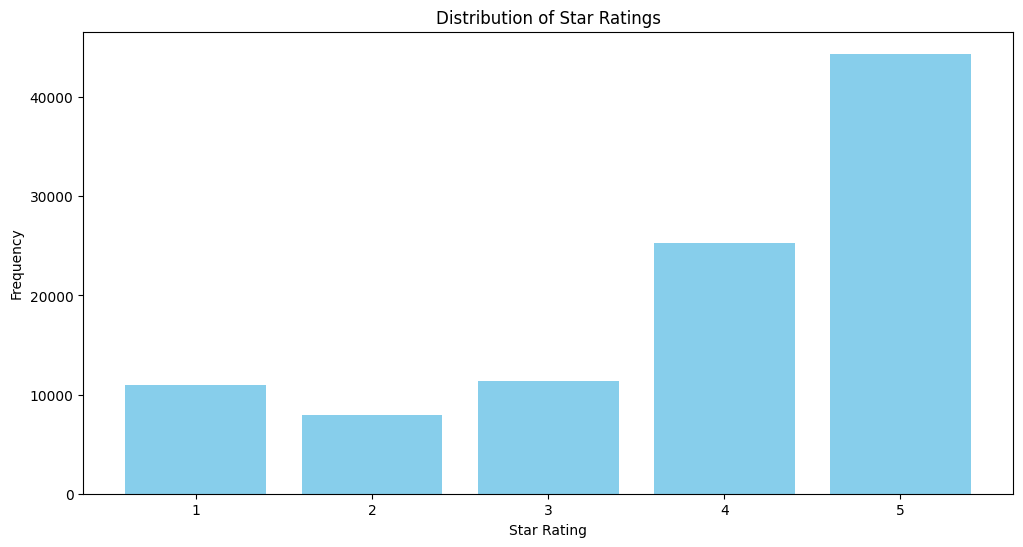

In [40]:

# Load the review data
reviews_df = pd.read_json('../data/raw/yelp_academic_dataset_review.json', lines=True, nrows=100000) # Load only the first 100,000 reviews for analysis. In the report, mention resource management and the decision to limit the dataset size for initial exploration.
reviews_df = reviews_df[['stars', 'text']] # Keep only the relevant columns

# Remove duplicates and drop empty rows from the dataset
reviews_df.drop_duplicates(inplace=True)
reviews_df = reviews_df.dropna(subset=['text'])
reviews_df = reviews_df[reviews_df['text'].str.strip() != '']


# Display the frequency of star ratings
star_counts = reviews_df['stars'].value_counts().sort_index()
print(star_counts)

# Display the basic information about the dataset
print(reviews_df.info())

# Display the first few review texts and their corresponding star ratings
print(reviews_df.head(10))  

# Define a function for plotting distributions per star rating
def plot_stars_distribution(dataframe):
    plt.figure(figsize=(12, 6))

    star_rating_counts = dataframe['stars'].value_counts().sort_index()

    plt.bar(star_rating_counts.index, star_rating_counts.values, color='skyblue')
    plt.xlabel('Star Rating')
    plt.ylabel('Frequency')
    plt.title('Distribution of Star Ratings')
    plt.show()

# Call the function to plot the distribution of star ratings
plot_stars_distribution(reviews_df)


# Data Preprocessing: lowercasing, removing punctuation, stopwords, html artifacts, and tokenization
stopwords_set = set(stopwords.words('english')) # Convert the stopwords list to a set for faster lookup during preprocessing

# Remove "no" and "not" from the stopwords list to preserve negation in sentiment analysis, as they can significantly change the meaning of a review (e.g., "not good" vs "good")
stopwords_set.discard('no')
stopwords_set.discard('not')

# Define a preprocessing function to clean the review texts
def preprocess_text(text):

    # Ensure the input is a string
    if not isinstance(text, str):
        return "" # Replace NaNs and other invalid values with an empty string to prevent errors during processing
    
    text = text.lower() # Convert to lowercase
    text = re.sub(r"<.*?>", "", text) # Remove HTML tags
    text = re.sub(r"[^a-zA-Z\s]", "", text) # Remove special characters
    text = re.sub(r"\d+", "", text) # Remove numbers
    tokens = word_tokenize(text) # Tokenize the text into words
    tokens = [word for word in tokens if word not in stopwords_set] # Remove stopwords using a list comprehension

    cleaned_text = " ".join(tokens) # Join the tokens back into a single string
    return cleaned_text

# Apply the preprocessing function to the review texts
reviews_df['cleaned_text'] = reviews_df['text'].apply(preprocess_text) # Create a new column for the cleaned review texts


# Filter the dataset to create a subset of reviews with only 1-star ratings
one_star_reviews = reviews_df[reviews_df['stars'] == 1]

# Analogously, create a subset of reviews with only 5-star ratings
five_star_reviews = reviews_df[reviews_df['stars'] == 5]


one_star_reviews_cleaned = one_star_reviews['cleaned_text']
five_star_reviews_cleaned = five_star_reviews['cleaned_text']

In [41]:
# Define a function for splitting texts into word lists and extracting the frequency counts of terms in the review text corpus
def get_word_counts(review_text):
    combined_review_text = " ".join(review_text)
    review_word_list = combined_review_text.split()
    word_counts = Counter(review_word_list)

    return review_word_list, word_counts

one_star_word_list, one_star_word_counts = get_word_counts(one_star_reviews_cleaned)
five_star_word_list, five_star_word_counts = get_word_counts(five_star_reviews_cleaned)

print(f"Most frequent 50 words in one star reviews: {one_star_word_counts.most_common(50)}")
print(f"Most frequent 50 words in five star reviews: {five_star_word_counts.most_common(50)}")

Most frequent 50 words in one star reviews: [('not', 12260), ('food', 6477), ('no', 5608), ('would', 4985), ('place', 4965), ('one', 4707), ('service', 4609), ('back', 4577), ('get', 4461), ('time', 4380), ('like', 4169), ('us', 4035), ('never', 3671), ('even', 3513), ('go', 3497), ('said', 3388), ('order', 3141), ('told', 3130), ('dont', 3046), ('good', 2959), ('got', 2958), ('didnt', 2876), ('minutes', 2819), ('ordered', 2711), ('asked', 2636), ('came', 2611), ('could', 2607), ('went', 2448), ('people', 2067), ('first', 1953), ('restaurant', 1908), ('ever', 1856), ('took', 1831), ('im', 1822), ('know', 1822), ('bad', 1822), ('another', 1815), ('customer', 1800), ('going', 1787), ('really', 1771), ('experience', 1763), ('manager', 1752), ('two', 1706), ('table', 1611), ('also', 1598), ('give', 1589), ('called', 1581), ('take', 1571), ('still', 1571), ('come', 1552)]
Most frequent 50 words in five star reviews: [('great', 25432), ('place', 20812), ('food', 19831), ('good', 16203), ('no

In [ ]:
# Convert the cleaned review text series into a list
one_star_texts = one_star_reviews_cleaned.tolist()
five_star_texts = five_star_reviews_cleaned.tolist()

# Merge all review texts for efficient TF-IDF comparison across documents
all_texts = one_star_texts + five_star_texts

In [ ]:
# Define a list of domain specific stopwords
domain_stopwords = ['would', 'place', 'one', 'back', 'get', 'us', 'even', 'go', 'said', 'told', 'go', 'got', 'im', 'came', 'could', 'went', 'asked', 'give', 'want', 'say', 'never', 'always', 'also']

# Initialize the TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words=domain_stopwords) # Limiting vocabulary size by setting the maximum number of features to 5000

# Fit TF-IDF on all data
tfidf_matrix = tfidf_vectorizer.fit_transform(all_texts)

# Display the learned vocabulary after fitting the data
print(f"The dictionary representation of the learned vocabulary: {tfidf_vectorizer.vocabulary_}\n")

# Splitting the TF-IDF matrix back into 1-star and 5-star review submatrices by index
tfidf_one_star_matrix = tfidf_matrix[:len(one_star_texts)] # Taking the first rows with one star texts
tfidf_five_star_matrix = tfidf_matrix[len(one_star_texts):] # Taking all the remaining texts

# Extract the feature (word) names
tfidf_words = tfidf_vectorizer.get_feature_names_out()

one_star_scores = np.asarray(tfidf_one_star_matrix.sum(axis=0)).flatten()
five_star_scores = np.asarray(tfidf_five_star_matrix.sum(axis=0)).flatten()

# Zip words and their respective scores into pair tuples
one_star_word_scores = list(zip(tfidf_words, one_star_scores))
five_star_word_scores = list(zip(tfidf_words, five_star_scores))

# Round the scores for readability
one_star_rounded = [(word, round(score, 1)) for word, score in one_star_word_scores]
five_star_rounded = [(word, round(score, 1)) for word, score in five_star_word_scores]

# Define a function to get the top words in both 1-star and 5-star texts
def get_top_words(word_scores, n=50):
    word_scores.sort(key=lambda score: score[1], reverse=True) # reverse the list so that the words with highest scores are displayed first
    return word_scores[:n]

top_1star_words = get_top_words(one_star_rounded)
top_5star_words = get_top_words(five_star_rounded)

print(f"Top 50 1-star TF-IDF words:{top_1star_words}")
print(f"Top 50 5-star TF-IDF words:{top_5star_words}")

The dictionary representation of the learned vocabulary: {'long': np.int64(2576), 'term': np.int64(4427), 'frequent': np.int64(1785), 'customer': np.int64(1135), 'establishment': np.int64(1500), 'order': np.int64(3027), 'take': np.int64(4360), 'apps': np.int64(200), 'theyre': np.int64(4457), 'busy': np.int64(617), 'really': np.int64(3514), 'maybe': np.int64(2701), 'half': np.int64(1996), 'full': np.int64(1819), 'best': np.int64(411), 'reach': np.int64(3504), 'ass': np.int64(244), 'yes': np.int64(4979), 'great': np.int64(1936), 'glad': np.int64(1879), 'kanella': np.int64(2381), 'opened': np.int64(3014), 'going': np.int64(1896), 'pay': np.int64(3149), 'everything': np.int64(1520), 'la': np.int64(2427), 'carte': np.int64(700), 'food': np.int64(1744), 'wasnt': np.int64(4826), 'terrible': np.int64(4430), 'not': np.int64(2949), 'impressive': np.int64(2219), 'brought': np.int64(568), 'basket': np.int64(350), 'chips': np.int64(816), 'tomato': np.int64(4521), 'sauce': np.int64(3775), 'politely'